# Kapitel 8

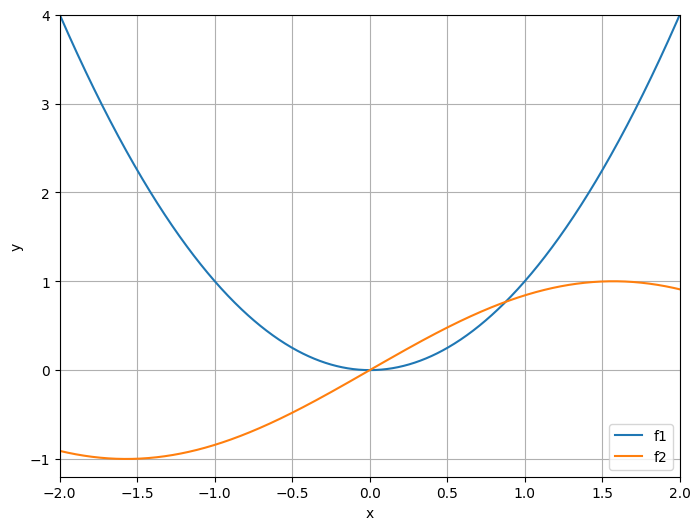

In [1]:
# Hilfsfunktion zum Plotten von Funktionen
import math
import numpy as np
import matplotlib.pyplot as plt
def plotFun(fs: list, xmin, xmax, ymin, ymax):
    x = np.linspace(xmin, xmax, 1000)
    plt.figure(figsize=(8, 6))
    for f in fs:
        y = []
        for xi in x:
            try:
                yi = f(xi)
                y.append(yi)
            except Exception: 
                y.append(np.nan)  # Fehlerhafte Auswertung → Lücke im Plot
        plt.plot(x, y, label=f.__name__ if hasattr(f, '__name__') else str(f)) 
    plt.xlim(xmin, xmax); plt.ylim(ymin, ymax)
    plt.xlabel("x"); plt.ylabel("y")
    plt.grid(True)
    plt.legend()
    plt.show()
def f1(x): return x**2
def f2(x): return math.sin(x)
plotFun([f1, f2], -2, 2, -1.2, 4)

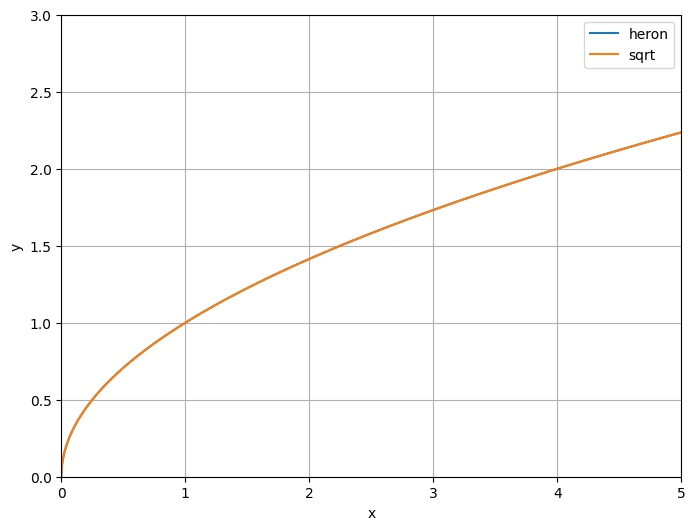

heron iterativ sqrt(2)= 1.4142135623746899


In [2]:
def heron(a:float,x0=1,eps=1e-7):
    if abs(x0**2-a)<eps:
        return x0
    return heron(a,(x0+a/x0)/2,eps)
plotFun([heron,math.sqrt], 0, 5, 0, 3)
def heronIterativ(a:float,x0=1,eps=1e-7):
    while abs(x0**2-a)>eps:
        x0=(x0+a/x0)/2
    return x0
print("heron iterativ sqrt(2)=",heronIterativ(2))

In [3]:
def Power(a:float,b:float,eps=1e-9)->float:
    if b<0:
        return 1/Power(a,-b,eps)
    if abs(b-1)<eps:
        return a
    if abs(b)<eps:
        return 1
    if b>1: 
        return a*Power(a,b-1,eps)
    if b<1:
        return Power(heron(a,eps=eps),2*b,eps)
print("8^(-1/3)=",Power(8,-1/3))

8^(-1/3)= 0.5000000002420177


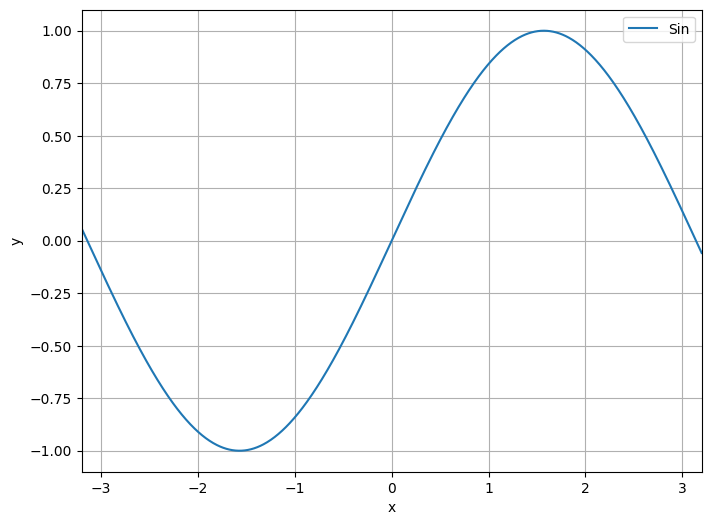

In [4]:
def Sin(x,eps=1e-7):
    if abs(x)<eps: 
        return x
    s3=Sin(x/3,eps)
    return 3*s3-4*s3**3 
plotFun([Sin], -3.2, 3.2, -1.1, 1.1)

PI= 3.141592656262219 pi= 3.141592653589793


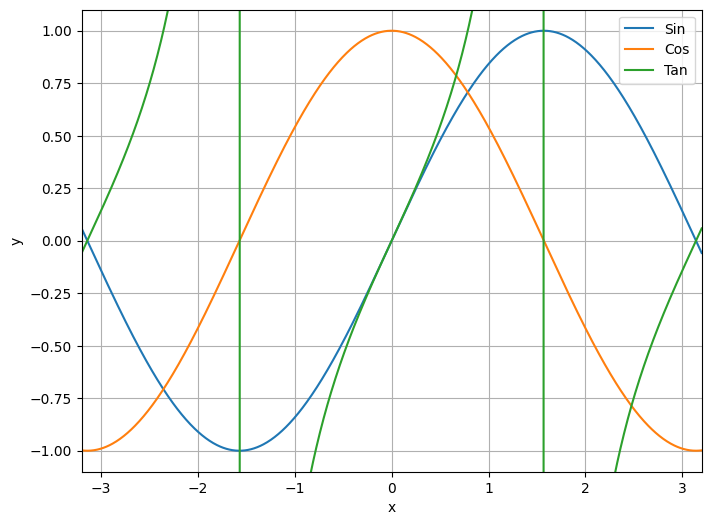

In [5]:
def Bisektion(f,a:float,b:float,eps=1e-8)->float:
    if f(a)*f(b)>0:
        raise Exception("Bisektion braucht unterschiedliche Vorzeichen")
    while abs(a-b)>eps:
        m=(a+b)/2 
        if f(a)*f(m)<0: # Nst zwischen a und m
            b=m
        else:
            a=m
    return (a+b)/2
PI= Bisektion(Sin,2,5)
print("PI=",PI,"pi=",math.pi)
def Cos(x):
    return Sin(x+PI/2)
def Tan(x):
    return Sin(x)/Cos(x)
plotFun([Sin,Cos,Tan], -3.2, 3.2, -1.1, 1.1)

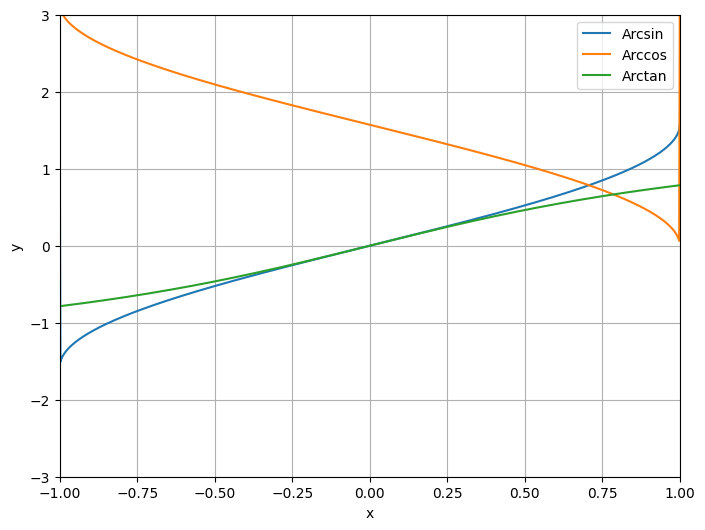

In [6]:
def Arcsin(x):
    if abs(x)>1:
        raise Exception("Arcsin(x) ist nur für |x|<=1 def.")
    def g(u):
        return Sin(u)-x
    return Bisektion(g,-PI/2,PI/2)
def Arccos(x):
    if abs(x)>1:
        raise Exception("Arccos(x) ist nur für |x|<=1 def.")
    def g(u):
        return Cos(u)-x
    return Bisektion(g,0,PI)
def Arctan(x):
    def g(u):
        return Tan(u)-x
    return Bisektion(g,-PI/2*0.999,0.999*PI/2)
plotFun([Arcsin,Arccos,Arctan], -1,1, -3, 3)

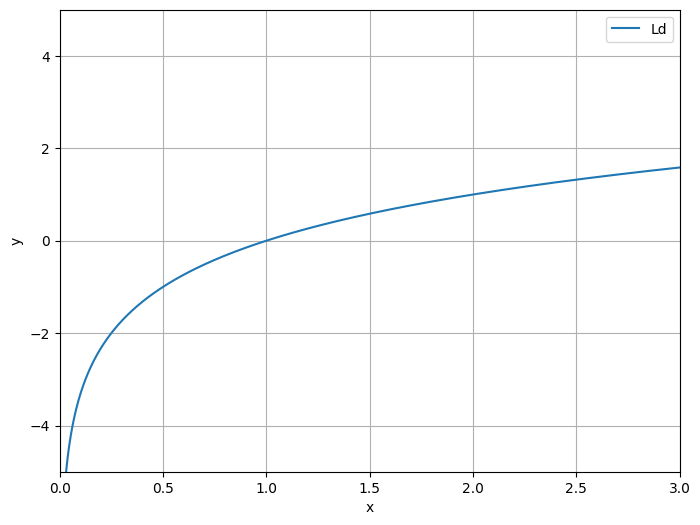

In [7]:
def Log(x,b,eps=1e-6): # log(x) zur Basis b
    if x<=0:
        raise Exception("log(x): x>0!")
    if abs(x-1)<eps:
        return 0
    def g(u):
        return Power(b,u,eps)-x
    return Bisektion(g,-1000,1000)
def Ld(x): # Log zur Basis 2
    return Log(x,2)
plotFun([Ld],0.0,3,-5,5)